# 04 — Integração TCC: o achado central

Aqui os três estudos se cruzam. Esse é o notebook que **diferencia o TCC**.

**Tese:** quando se avalia apenas correção (notebook 1), os 9 modelos API parecem
quase equivalentes (todos acima de 0.91). Mas a experiência do usuário não é só
correção — é correção *entregue de forma útil*. Quando se introduz o rubric de
correção+foco (notebook 3), a hierarquia muda completamente, e a variável que
explica essa mudança é uma só: **quantidade de tokens**.

Este notebook produz o Excel mestre `tcc_analise_integrada.xlsx`.

In [ ]:
# Setup comum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_AVALIADOR = {'gpt': '#10A37F', 'opus': '#D97757', 'humano': '#8E44AD'}
PALETA_TIPO = {'api': '#2E86AB', 'chat': '#E74C3C'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

# Detecta a pasta data/ automaticamente — tenta vários caminhos
def find_data_dir():
    candidatos = [Path('.'), Path('data'), Path('../data'), Path('../../data'),
                  Path('./data'), Path('../../../data')]
    for p in candidatos:
        if (p / 'df_avaliacoes.xlsx').exists():
            return p.resolve()
    raise FileNotFoundError(
        'Não encontrei df_avaliacoes.xlsx. Coloque os 5 arquivos .xlsx '
        'em ./data/, ../data/, ou no mesmo diretório do notebook, ou edite '
        'a variável DATA manualmente abaixo.'
    )

DATA = find_data_dir()
INTER = DATA.parent / 'output' / 'intermediarios'
INTER.mkdir(parents=True, exist_ok=True)
print(f'DATA  = {DATA}')
print(f'INTER = {INTER}')

## 1. Carregamento dos dataframes intermediários

In [ ]:
# Carrega e prepara tudo direto dos 5 arquivos brutos (sem .pkl)
from sklearn.metrics import cohen_kappa_score

# Tokenizador
try:
    import tiktoken
    ENC = tiktoken.get_encoding('cl100k_base')
    def _count_tokens(s):
        return 0 if not isinstance(s, str) or not s else len(ENC.encode(s))
except Exception:
    def _count_tokens(s):
        return 0 if not isinstance(s, str) or not s else int(round(len(s.split()) / 0.75))

CHAT_NAME_MAP = {'std_chatgpt': 'chatgpt', 'std_claude': 'claude_chat'}

# --- Estudo 1: qualidade API com avaliacao_final
df_av  = pd.read_excel(DATA / 'df_avaliacoes.xlsx')
df_me  = pd.read_excel(DATA / 'df_metricas.xlsx')
df_div = pd.read_excel(DATA / 'divergentes_human_eval.xlsx')
df_div[['edital_h','modelo_h']] = df_div['pasta'].str.split('_', n=1, expand=True)
lookup = (df_div[['edital_h','modelo_h','id','Avaliação Humana','Modelo Correto']]
          .rename(columns={'edital_h':'edital','modelo_h':'modelo',
                           'Avaliação Humana':'avaliacao_humana',
                           'Modelo Correto':'modelo_correto'}))
df_av = df_av.merge(lookup, on=['edital','modelo','id'], how='left')
df_av['avaliacao_final'] = np.where(df_av['convergencia'],
                                     df_av['avaliacao_gpt'], df_av['avaliacao_humana'])
df_av['nota_consenso'] = (df_av['avaliacao_gpt'] + df_av['avaliacao_opus']) / 2

# Métricas operacionais (uma linha por pergunta×modelo)
df_op = df_me[df_me['avaliador'] == 'gpt'].copy()

# --- Estudo 2: divergências dos chats
df_chat_div = pd.read_excel(DATA / 'chats_div_avaliado.xlsx')
df_chat_div['modelo'] = df_chat_div['modelo'].replace(CHAT_NAME_MAP)
df_chat_div = df_chat_div.rename(columns={'avaliação humana':'avaliacao_humana',
                                          'modelo.1':'modelo_correto'})

# --- Estudo 3: rubric unificado com tokens
df_uni = pd.read_excel(DATA / 'analise_consolidada.xlsx')
df_uni['n_tokens']   = df_uni['resposta'].fillna('').astype(str).apply(_count_tokens)
df_uni['n_palavras'] = df_uni['resposta'].fillna('').astype(str).str.split().str.len().fillna(0).astype(int)

# --- Ranking unificado
qual_api = df_av.groupby(['modelo','provedor']).agg(
    avaliacao_final=('avaliacao_final','mean'),
    nota_consenso=('nota_consenso','mean'),
    convergencia_gpt_opus=('convergencia','mean'),
    n_divergencias=('convergencia', lambda x: (~x).sum()),
).reset_index()
qual_chat = (df_uni[df_uni['tipo']=='chat']
             .groupby(['modelo','provider']).agg(score_rubric=('score','mean'))
             .reset_index().rename(columns={'provider':'provedor'}))
score_rubric_todos = df_uni.groupby('modelo')['score'].mean().rename('score_rubric').reset_index()
tokens_api = df_op.groupby('modelo')['output_tokens'].mean().rename('output_tokens_real').reset_index()
tokens_chat = (df_uni[df_uni['tipo']=='chat'].groupby('modelo')['n_tokens']
               .mean().rename('output_tokens_real').reset_index())
tokens_todos = pd.concat([tokens_api, tokens_chat], ignore_index=True)
lat_api = df_op.groupby('modelo')['latencia_s'].median().rename('latencia_mediana').reset_index()

ranking = qual_api.copy()
ranking['tipo'] = 'api'
ranking_chat = qual_chat.copy()
ranking_chat['tipo'] = 'chat'
ranking_chat['avaliacao_final'] = np.nan
ranking_chat['nota_consenso'] = np.nan
ranking_chat['convergencia_gpt_opus'] = np.nan
ranking_chat['n_divergencias'] = (df_chat_div.groupby('modelo').size()
                                   .reindex(ranking_chat['modelo']).fillna(0).values)
cols_pad = ['modelo','provedor','avaliacao_final','nota_consenso',
            'convergencia_gpt_opus','n_divergencias','tipo']
ranking = pd.concat([ranking[cols_pad], ranking_chat[cols_pad]], ignore_index=True)
ranking = (ranking.merge(score_rubric_todos, on='modelo', how='left')
           .merge(tokens_todos, on='modelo', how='left')
           .merge(lat_api, on='modelo', how='left')
           .sort_values('score_rubric', ascending=False).reset_index(drop=True))

# --- Divergências consolidadas
div_api = df_av[~df_av['convergencia']][['edital','modelo','provedor','id','categoria',
    'avaliacao_gpt','avaliacao_opus','avaliacao_humana','modelo_correto']].copy()
div_api['fonte'] = 'api'
div_chat = df_chat_div[['edital','modelo','provedor','id','categoria',
    'avaliacao_gpt','avaliacao_opus','avaliacao_humana','modelo_correto']].copy()
div_chat['fonte'] = 'chat'
divs = pd.concat([div_api, div_chat], ignore_index=True)

print(f'df_av (API qualidade):    {df_av.shape}')
print(f'df_op (API métricas):     {df_op.shape}')
print(f'df_uni (rubric unif.):    {df_uni.shape}')
print(f'ranking unificado:        {ranking.shape}')
print(f'divergências (121):       {divs.shape}')

## 2. O achado central: correção × concisão (9 modelos API)

In [3]:
api_qual  = df_av.groupby('modelo')['avaliacao_final'].mean()
api_score = df_uni[df_uni['tipo']=='api'].groupby('modelo')['score'].mean()
api_tok   = df_op.groupby('modelo')['output_tokens'].mean()
api_lat   = df_op.groupby('modelo')['latencia_s'].median()
api_prov  = df_av.groupby('modelo')['provedor'].first()

cross = pd.DataFrame({
    'avaliacao_final': api_qual,
    'score_rubric': api_score,
    'output_tokens': api_tok,
    'latencia': api_lat,
    'provedor': api_prov,
}).reset_index()

r1, p1 = stats.pearsonr(cross['avaliacao_final'], cross['score_rubric'])
r2, p2 = stats.pearsonr(cross['output_tokens'], cross['score_rubric'])
r3, p3 = stats.pearsonr(cross['output_tokens'], cross['avaliacao_final'])

print('Correlações (n=9 modelos API):')
print(f'  avaliacao_final × score_rubric: r={r1:+.3f} (p={p1:.3f})  → praticamente ZERO')
print(f'  tokens × score_rubric:          r={r2:+.3f} (p={p2:.3f})  → FORTE negativa')
print(f'  tokens × avaliacao_final:       r={r3:+.3f} (p={p3:.3f})  → não significativa')
print()
print('Leitura: a correção (avaliacao_final) varia pouco entre modelos.')
print('A concisão (score_rubric) varia muito, e é prevista quase totalmente por tokens.')
cross.round(4)

Correlações (n=9 modelos API):
  avaliacao_final × score_rubric: r=+0.035 (p=0.928)  → praticamente ZERO
  tokens × score_rubric:          r=-0.821 (p=0.007)  → FORTE negativa
  tokens × avaliacao_final:       r=+0.486 (p=0.185)  → não significativa

Leitura: a correção (avaliacao_final) varia pouco entre modelos.
A concisão (score_rubric) varia muito, e é prevista quase totalmente por tokens.


,modelo,avaliacao_final,score_rubric,output_tokens,latencia,provedor
0,claude-haiku-4-5,0.9367,0.6767,460.3733,12.955,anthropic
1,claude-opus-4-7,0.9767,0.6733,595.1800,10.620,anthropic
2,claude-sonnet-4-6,0.9733,0.6167,567.3067,11.675,anthropic
3,deepseek-v4-flash,0.9700,0.6900,429.0067,7.505,deepseek
4,deepseek-v4-pro,0.9633,0.6933,475.7467,15.850,deepseek
5,gpt-4o-mini,0.9100,0.7600,182.7467,5.200,openai
6,gpt-5.4,0.9633,0.9267,178.5533,4.890,openai
7,gpt-5.4-mini,0.9067,0.8200,172.9267,2.665,openai
8,gpt-5.5,0.9967,0.9300,263.0800,19.505,openai


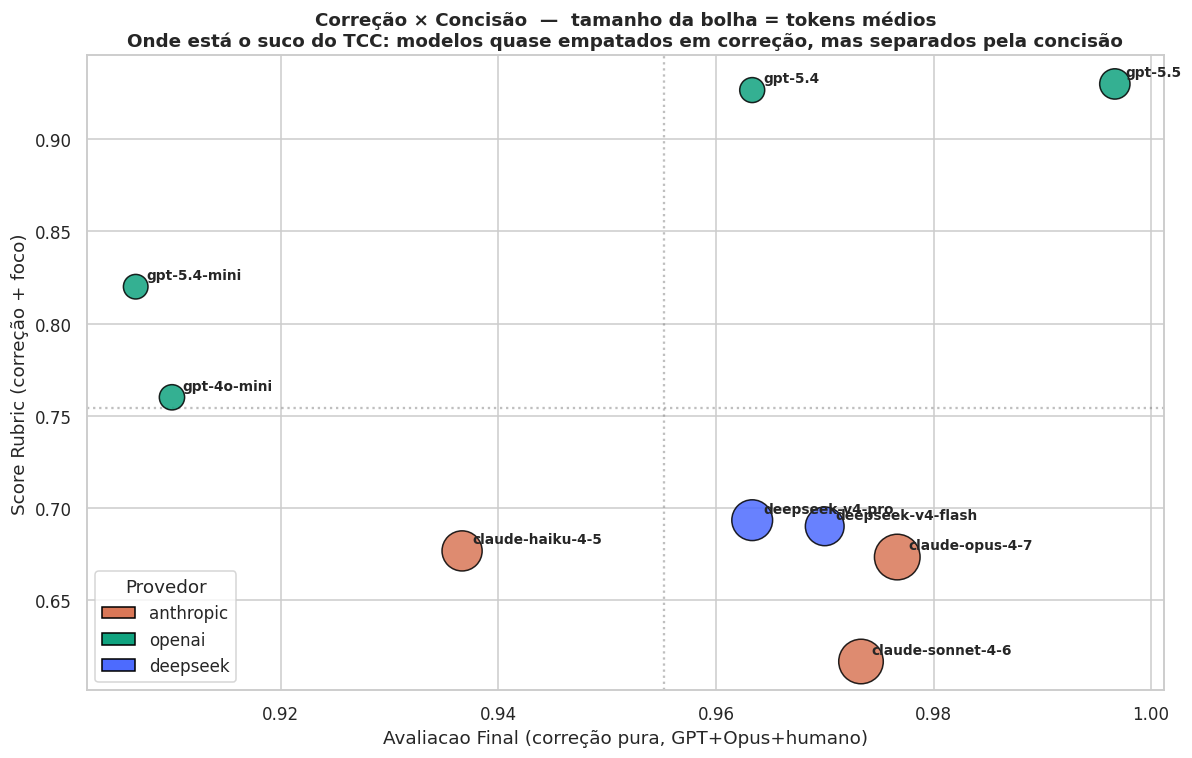

In [4]:
# Gráfico de dois eixos: avaliacao_final no eixo X, score_rubric no Y
fig, ax = plt.subplots(figsize=(11, 7))
cores = [PALETA_PROVEDOR[p] for p in cross['provedor']]
ax.scatter(cross['avaliacao_final'], cross['score_rubric'],
           c=cores, s=cross['output_tokens']*1.5,
           edgecolor='black', linewidth=1, alpha=0.85, zorder=3)
for _, r in cross.iterrows():
    ax.annotate(r['modelo'], (r['avaliacao_final'], r['score_rubric']),
                xytext=(7, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# Linhas de média
ax.axvline(cross['avaliacao_final'].mean(), ls=':', color='gray', alpha=0.5)
ax.axhline(cross['score_rubric'].mean(), ls=':', color='gray', alpha=0.5)
ax.set_xlabel('Avaliacao Final (correção pura, GPT+Opus+humano)')
ax.set_ylabel('Score Rubric (correção + foco)')
ax.set_title('Correção × Concisão  —  tamanho da bolha = tokens médios\n'
             'Onde está o suco do TCC: modelos quase empatados em correção, mas separados pela concisão')

legend = [mpatches.Patch(facecolor=c, edgecolor='black', label=p)
          for p,c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, loc='lower left', title='Provedor')
plt.tight_layout(); plt.show()

## 3. Quadrante 2×2: correto × focado

In [5]:
# Em cada linha de df_uni (que tem 11 modelos) classificar o avaliacao_final
# Para os 9 API: usa o avaliacao_final do estudo 1
# Para os 2 chats: não temos avaliacao_final puro, usamos o próprio score

df_uni_q = df_uni.copy()

# Para API, juntar avaliacao_final
av_lookup = df_av.set_index(['edital','modelo','id'])['avaliacao_final']
df_uni_q = df_uni_q.set_index(['edital','modelo','id'])
df_uni_q['avaliacao_final'] = av_lookup
df_uni_q = df_uni_q.reset_index()

# Para chat, usar score como proxy de correção (já que não temos outra medida)
df_uni_q['avaliacao_final'] = df_uni_q['avaliacao_final'].fillna(df_uni_q['score'])

# Definir quadrantes (só para API, onde temos as duas medidas independentes)
api_only = df_uni_q[df_uni_q['tipo']=='api'].copy()
api_only['correto'] = api_only['avaliacao_final'] >= 0.75
api_only['focado']  = api_only['score'] >= 0.75

quad = pd.crosstab(api_only['focado'], api_only['correto'],
                   margins=True, margins_name='Total')
quad = quad.rename(index={True: 'Focado (score≥0.75)', False: 'Verboso (score<0.75)'},
                   columns={True: 'Correto (final≥0.75)', False: 'Incorreto (final<0.75)'})
print('Quadrantes nos 1.350 casos API:')
print(quad)
print()
print('Interpretação:')
print('  - Correto + Focado:    ideal — resposta certa, sem enrolação')
print('  - Correto + Verboso:   a "armadilha Claude" — a verdade afogada em texto')
print('  - Incorreto + Focado:  raro — diz a coisa errada de forma curta')
print('  - Incorreto + Verboso: pior — alucinação enrolada')

Quadrantes nos 1.350 casos API:
correto               Incorreto (final<0.75)  Correto (final≥0.75)  Total
focado                                                                   
Verboso (score<0.75)                     107                   526    633
Focado (score≥0.75)                        3                   714    717
Total                                    110                  1240   1350

Interpretação:
  - Correto + Focado:    ideal — resposta certa, sem enrolação
  - Correto + Verboso:   a "armadilha Claude" — a verdade afogada em texto
  - Incorreto + Focado:  raro — diz a coisa errada de forma curta
  - Incorreto + Verboso: pior — alucinação enrolada


## 4. API vs Chat: vale a pena a ferramenta customizada?

In [6]:
comp = []
for prov in ['openai', 'anthropic']:
    api_rows = ranking[(ranking['tipo']=='api') & (ranking['provedor']==prov)]
    chat_rows = ranking[(ranking['tipo']=='chat') & (ranking['provedor']==prov)]
    if len(api_rows)==0 or len(chat_rows)==0: continue
    melhor = api_rows.iloc[0]
    chat = chat_rows.iloc[0]
    comp.append({
        'provedor': prov,
        'melhor_api': melhor['modelo'],
        'score_api': melhor['score_rubric'],
        'tokens_api': melhor['output_tokens_real'],
        'chat': chat['modelo'],
        'score_chat': chat['score_rubric'],
        'tokens_chat': chat['output_tokens_real'],
    })
comp_df = pd.DataFrame(comp).round(3)
print('Comparação API vs Chat (mesmo provedor):')
print(comp_df.to_string(index=False))
print()
print('Observação: em ambos os provedores, o melhor modelo API tem score maior')
print('que o chat — mostrando que a ferramenta customizada via API supera o')
print('chat genérico com o mesmo provedor base.')

Comparação API vs Chat (mesmo provedor):
 provedor       melhor_api  score_api  tokens_api        chat  score_chat  tokens_chat
   openai          gpt-5.5      0.930     263.080     chatgpt       0.833       51.340
anthropic claude-haiku-4-5      0.677     460.373 claude_chat       0.513      423.493

Observação: em ambos os provedores, o melhor modelo API tem score maior
que o chat — mostrando que a ferramenta customizada via API supera o
chat genérico com o mesmo provedor base.


## 5. Eficiência de custo: tokens × score por modelo

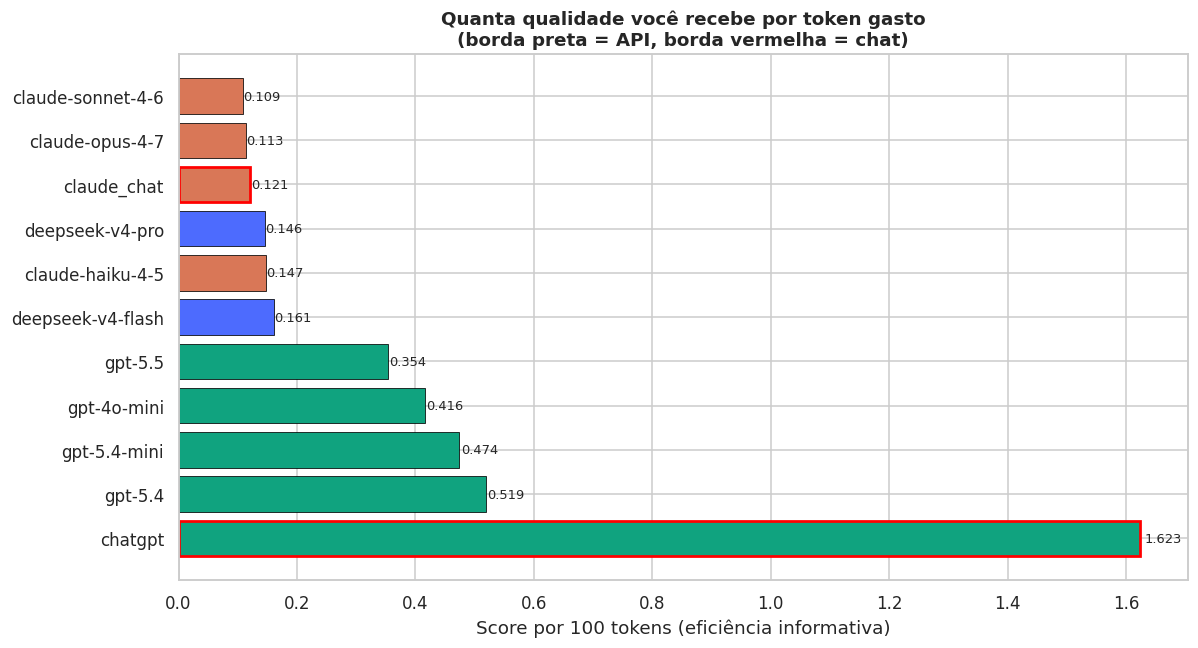

In [7]:
# Score por token (eficiência informativa)
ranking_eff = ranking.copy()
ranking_eff['score_por_100tokens'] = (ranking_eff['score_rubric'] /
                                       ranking_eff['output_tokens_real'] * 100)
ranking_eff = ranking_eff.sort_values('score_por_100tokens', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
cores = [PALETA_PROVEDOR[p] for p in ranking_eff['provedor']]
edges = ['black' if t=='api' else 'red' for t in ranking_eff['tipo']]
lw = [0.5 if t=='api' else 1.8 for t in ranking_eff['tipo']]
bars = ax.barh(ranking_eff['modelo'], ranking_eff['score_por_100tokens'],
               color=cores, edgecolor=edges, linewidth=lw)
ax.set_xlabel('Score por 100 tokens (eficiência informativa)')
ax.set_title('Quanta qualidade você recebe por token gasto\n'
             '(borda preta = API, borda vermelha = chat)')
for bar, v in zip(bars, ranking_eff['score_por_100tokens']):
    ax.text(v * 1.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8.5)
plt.tight_layout(); plt.show()

## 6. Heatmap: dificuldade por categoria de pergunta

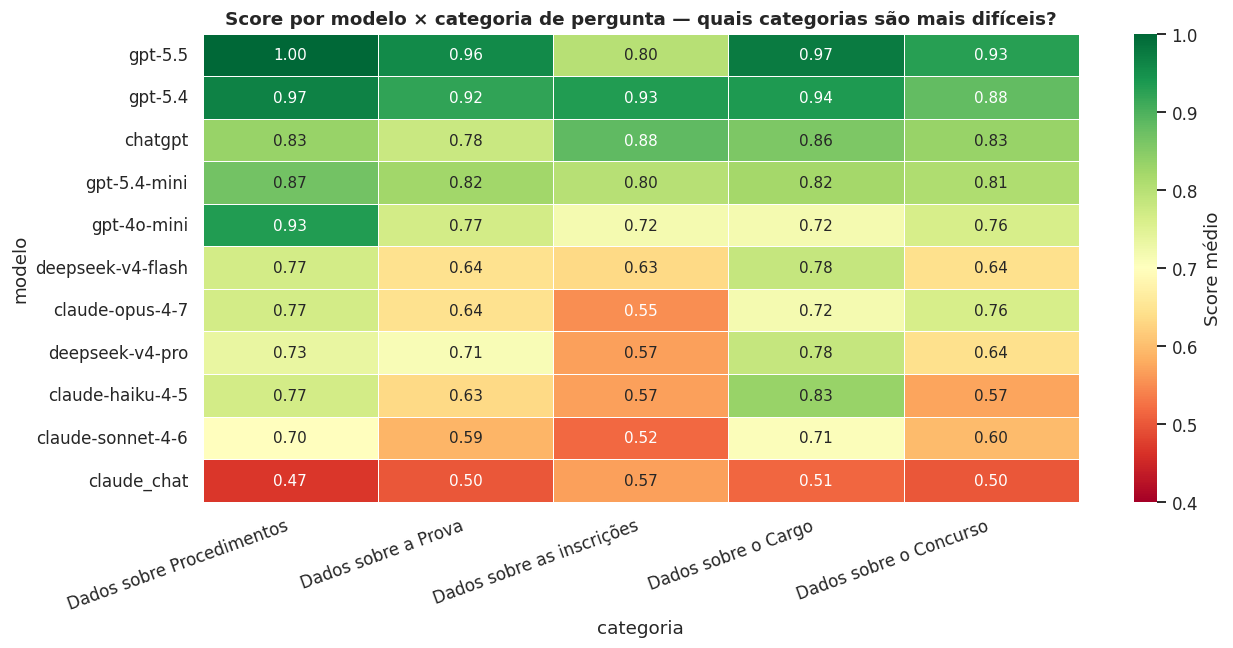


Categorias mais difíceis (média entre todos os modelos):
categoria
Dados sobre as inscrições    0.684848
Dados sobre o Concurso       0.720779
Dados sobre a Prova          0.724242
Dados sobre o Cargo          0.785548
Dados sobre Procedimentos    0.800000


In [8]:
heat = df_uni.pivot_table(index='modelo', columns='categoria',
                          values='score', aggfunc='mean')
heat['média'] = heat.mean(axis=1)
heat = heat.sort_values('média', ascending=False).drop(columns='média')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
            cbar_kws={'label':'Score médio'}, linewidths=0.5, ax=ax)
ax.set_title('Score por modelo × categoria de pergunta — quais categorias são mais difíceis?')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()

print('\nCategorias mais difíceis (média entre todos os modelos):')
print(df_uni.groupby('categoria')['score'].mean().sort_values().to_string())

## 7. Resumo executivo

In [9]:
print('━' * 70)
print('  RESUMO EXECUTIVO DO ESTUDO INTEGRADO')
print('━' * 70)
print()
print('Modelos avaliados: 11 (9 API + 2 chats)')
print('Editais: 3 (BNDES, CVM, Petrobras)')
print('Perguntas por edital: 50  →  total: 1.650 respostas')
print()
print('─' * 70)
print('  ACHADO 1 — Os modelos quase empatam em correção pura')
print('─' * 70)
api_final = df_av.groupby('modelo')['avaliacao_final'].mean()
print(f'avaliacao_final (correção via 2 juízes + humano): '
      f'{api_final.min():.3f} a {api_final.max():.3f}')
print(f'Spread: {(api_final.max() - api_final.min()):.3f}')
print()
print('─' * 70)
print('  ACHADO 2 — Os modelos diferem muito em concisão')
print('─' * 70)
score_rub = df_uni.groupby('modelo')['score'].mean()
print(f'score do rubric unificado: {score_rub.min():.3f} a {score_rub.max():.3f}')
print(f'Spread: {(score_rub.max() - score_rub.min()):.3f}  ({(score_rub.max()-score_rub.min())/(api_final.max()-api_final.min()):.1f}× maior que o spread da correção)')
print()
print('─' * 70)
print('  ACHADO 3 — A concisão é prevista pelos tokens')
print('─' * 70)
api_subset = df_uni[df_uni['tipo']=='api'].groupby('modelo').agg(
    score=('score','mean'), tokens=('n_tokens','mean'))
r, p = stats.pearsonr(api_subset['tokens'], api_subset['score'])
print(f'Pearson (tokens × score) nos 9 API: r={r:+.3f} (p={p:.3f})')
print()
print('─' * 70)
print('  ACHADO 4 — Ranking de provedores por concisão')
print('─' * 70)
print(df_uni.groupby('provider')[['score','n_tokens']].mean().round(2).to_string())
print()
print('━' * 70)
print('  CONCLUSÃO PARA O TCC')
print('━' * 70)
print('A escolha de LLM para uso em editais não é uma questão de correção,')
print('é uma questão de concisão. Todos os modelos modernos conseguem extrair')
print('a informação correta do edital. A diferença de utilidade real está em')
print('como eles entregam essa informação — direto ao ponto ou afogada em')
print('texto não solicitado.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESUMO EXECUTIVO DO ESTUDO INTEGRADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Modelos avaliados: 11 (9 API + 2 chats)
Editais: 3 (BNDES, CVM, Petrobras)
Perguntas por edital: 50  →  total: 1.650 respostas

──────────────────────────────────────────────────────────────────────
  ACHADO 1 — Os modelos quase empatam em correção pura
──────────────────────────────────────────────────────────────────────
avaliacao_final (correção via 2 juízes + humano): 0.907 a 0.997
Spread: 0.090

──────────────────────────────────────────────────────────────────────
  ACHADO 2 — Os modelos diferem muito em concisão
──────────────────────────────────────────────────────────────────────
score do rubric unificado: 0.513 a 0.930
Spread: 0.417  (4.6× maior que o spread da correção)

──────────────────────────────────────────────────────────────────────
  ACHADO 3 — A concisão é prevista pelos tokens
────────